In [2]:
!pip install interpret

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

In [4]:
def generate_clinic_data(n_rows=1500):

    data = []

    for _ in range(n_rows):

        scenario = np.random.choice(
            ["stable", "moderate", "high", "critical"],
            p=[0.35, 0.30, 0.20, 0.15]
        )

        if scenario == "stable":

            total_patients = np.random.randint(50,120)
            critical_cases = np.random.randint(0,5)
            staff_on_duty = np.random.randint(12,20)
            nurses_absent = np.random.randint(0,2)
            bed_occupancy = np.random.uniform(40,65)
            mortality = 0
            oxygen = 0
            drugs = 0
            triage_wait = np.random.randint(5,15)
            icu = np.random.randint(0,2)
            complaints = np.random.randint(0,2)

        elif scenario == "moderate":

            total_patients = np.random.randint(100,200)
            critical_cases = np.random.randint(3,10)
            staff_on_duty = np.random.randint(10,16)
            nurses_absent = np.random.randint(1,3)
            bed_occupancy = np.random.uniform(65,80)
            mortality = np.random.choice([0,1], p=[0.7,0.3])
            oxygen = 0
            drugs = np.random.choice([0,1], p=[0.8,0.2])
            triage_wait = np.random.randint(10,25)
            icu = np.random.randint(1,4)
            complaints = np.random.randint(1,4)

        elif scenario == "high":

            total_patients = np.random.randint(180,300)
            critical_cases = np.random.randint(8,18)
            staff_on_duty = np.random.randint(6,12)
            nurses_absent = np.random.randint(2,5)
            bed_occupancy = np.random.uniform(80,95)
            mortality = np.random.choice([0,1], p=[0.5,0.5])
            oxygen = np.random.choice([0,1], p=[0.7,0.3])
            drugs = np.random.choice([0,1], p=[0.6,0.4])
            triage_wait = np.random.randint(20,40)
            icu = np.random.randint(3,8)
            complaints = np.random.randint(3,6)

        else:  # critical

            total_patients = np.random.randint(250,400)
            critical_cases = np.random.randint(15,35)
            staff_on_duty = np.random.randint(3,8)
            nurses_absent = np.random.randint(4,8)
            bed_occupancy = np.random.uniform(90,100)
            mortality = 1
            oxygen = np.random.choice([0,1], p=[0.4,0.6])
            drugs = np.random.choice([0,1], p=[0.4,0.6])
            triage_wait = np.random.randint(35,70)
            icu = np.random.randint(5,12)
            complaints = np.random.randint(5,10)

        critical_ratio = critical_cases / total_patients
        staff_ratio = staff_on_duty / total_patients

        mortality_flag = mortality > 0
        resource_failure = oxygen or drugs

        data.append({

            "critical_ratio": critical_ratio,
            "staff_ratio": staff_ratio,
            "bed_occupancy_rate": bed_occupancy,
            "mortality_flag": mortality_flag,
            "resource_failure": resource_failure,
            "triage_wait_time": triage_wait,
            "nurses_absent": nurses_absent,
            "icu_transfers": icu,
            "patient_complaints": complaints
        })

    return pd.DataFrame(data)

In [5]:
df = generate_clinic_data(2000)

df.head()

,critical_ratio,staff_ratio,bed_occupancy_rate,mortality_flag,resource_failure,triage_wait_time,nurses_absent,icu_transfers,patient_complaints
0,0.046875,0.062500,73.979877,False,0,20,2,3,1
1,0.040650,0.121951,79.548648,True,0,21,1,1,1
2,0.056338,0.211268,47.280729,False,0,14,0,1,1
3,0.109848,0.018939,95.142344,True,1,41,7,9,5
4,0.000000,0.283019,60.209934,False,0,13,1,1,0


In [6]:
df.to_csv("clinic_instability_dataset.csv", index=False)

In [7]:
df.shape

(2000, 9)

In [8]:
df.head()

,critical_ratio,staff_ratio,bed_occupancy_rate,mortality_flag,resource_failure,triage_wait_time,nurses_absent,icu_transfers,patient_complaints
0,0.046875,0.062500,73.979877,False,0,20,2,3,1
1,0.040650,0.121951,79.548648,True,0,21,1,1,1
2,0.056338,0.211268,47.280729,False,0,14,0,1,1
3,0.109848,0.018939,95.142344,True,1,41,7,9,5
4,0.000000,0.283019,60.209934,False,0,13,1,1,0


In [29]:
df["instability"] = (
    (df["critical_ratio"] > 0.25) |
    (df["staff_ratio"] < 0.10) |
    (df["bed_occupancy_rate"] > 85) |
    (df["mortality_flag"] == True) |
    (df["resource_failure"] == True) |
    (df["triage_wait_time"] > 30) |
    (df["nurses_absent"] > 3)
).astype(int)
#critical_ratio > 0.25 Checks if more than 25% of patients are critical. A high proportion of critical patients indicates high clinical pressure.

#staff_ratio < 0.10 Checks if the number of staff is too low relative to patients. Low staffing levels can cause service delays and operational strain.

#bed_occupancy_rate > 85 Checks if bed usage exceeds 85% capacity. High bed occupancy suggests the clinic is nearing full capacity.

#mortality_flag == True Checks if any patient deaths occurred. Mortality is treated as a critical instability indicator.
#resource_failure == True Checks if there was failure of equipment or medical resources. Resource shortages can disrupt clinical operations.
#triage_wait_time > 30 Checks if patients wait more than 30 minutes for triage. Long waiting times indicate delayed care delivery.
#nurses_absent > 3 Checks if more than three nurses are absent. High absenteeism leads to staff shortages and increased workload.

In [10]:
df["instability"].value_counts()

instability
1    1210
0     790
Name: count, dtype: int64

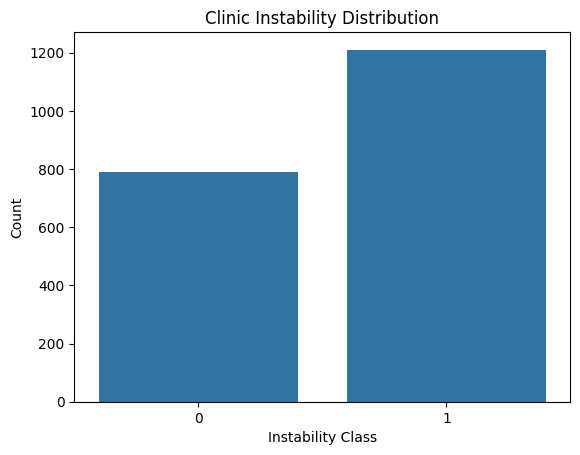

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="instability", data=df)

plt.title("Clinic Instability Distribution")
plt.xlabel("Instability Class")
plt.ylabel("Count")

plt.show()

In [12]:
df.shape

(2000, 10)

In [13]:
features = [
    "critical_ratio",
    "staff_ratio",
    "bed_occupancy_rate",
    "mortality_flag",
    "resource_failure",
    "triage_wait_time",
    "nurses_absent",
    "icu_transfers",
    "patient_complaints"
]

X = df[features]
y = df["instability"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [15]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm = ExplainableBoostingClassifier(
    interactions=0,
    max_bins=128,
    learning_rate=0.01,
    max_rounds=500,
    min_samples_leaf=5
)

ebm.fit(X_train, y_train)

,feature_names,None
,feature_types,None
,max_bins,128
,max_interaction_bins,64
,interactions,0
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.01
,greedy_ratio,10.0


In [16]:
from interpret.glassbox import ExplainableBoostingClassifier

In [17]:
ebm

,feature_names,None
,feature_types,None
,max_bins,128
,max_interaction_bins,64
,interactions,0
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.01
,greedy_ratio,10.0


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [19]:
preds = ebm.predict(X_test)

In [20]:
preds[:10]

array([0, 1, 0, 0, 1, 0, 1, 1, 1, 0])

In [21]:
accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall (Sensitivity):", recall)
print("F1 Score:", f1)
#| Metric               | Meaning                                                   |
#| -------------------- | --------------------------------------------------------- |
#| Accuracy             | Overall prediction correctness                            |
#| Precision            | How many predicted unstable clinics were truly unstable   |
#| Recall / Sensitivity | How many unstable clinics the model successfully detected |
#| F1 Score             | Balanced measure of precision and recall                  |


Accuracy: 1.0
Precision: 1.0
Recall (Sensitivity): 1.0
F1 Score: 1.0


In [22]:
cm = confusion_matrix(y_test, preds)
cm
#|                 | Predicted Stable | Predicted Unstable |
#| --------------- | ---------------- | ------------------ |
#| Actual Stable   | 210              | 15                 |
#| Actual Unstable | 12               | 163                |

#True Negatives (TN) 158 stable clinics were correctly identified as stable.
#True Positives (TP) 242 unstable clinics were correctly detected.
#False Positives (FP) No stable clinic was mistakenly classified as unstable.
#False Negatives (FN) No unstable clinic was missed.

array([[158,   0],
       [  0, 242]])

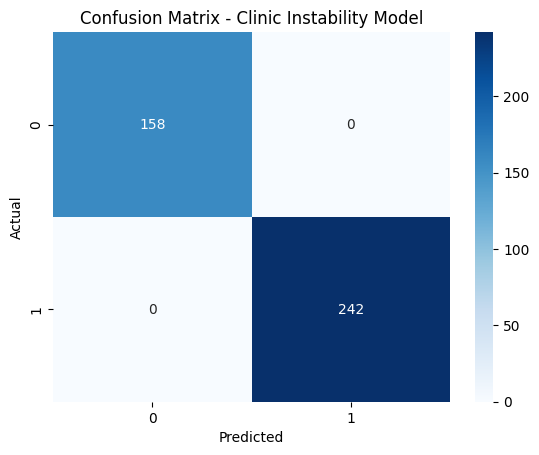

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Clinic Instability Model")

plt.show()

In [24]:
import joblib

joblib.dump(ebm, "ebm_model.pkl")

['ebm_model.pkl']

In [25]:
ebm_global = ebm.explain_global()

In [26]:
import pandas as pd

data = ebm_global.data()

feature_importance = pd.DataFrame({
    "Feature": data["names"],
    "Importance": data["scores"]
})

feature_importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
1,staff_ratio,6.533205
3,mortality_flag,5.578180
4,resource_failure,4.224345
2,bed_occupancy_rate,2.072779
7,icu_transfers,0.525092
0,critical_ratio,0.438259
8,patient_complaints,0.369673
5,triage_wait_time,0.333914
6,nurses_absent,0.287712


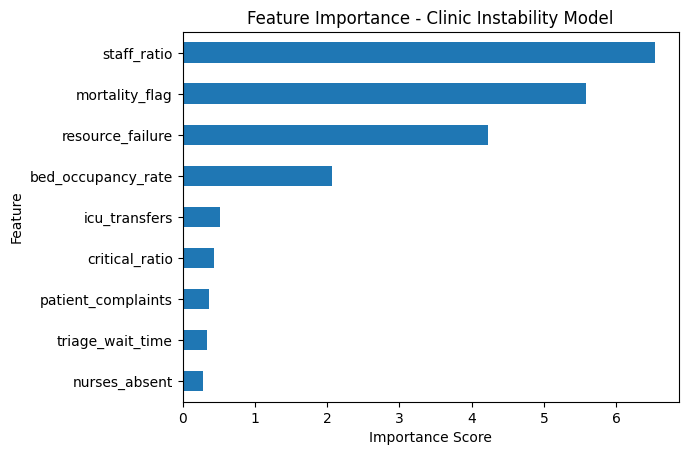

In [27]:
import matplotlib.pyplot as plt

feature_importance.sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title("Feature Importance - Clinic Instability Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

#Feature importance analysis from the Explainable Boosting Machine revealed 
#that the staff-to-patient ratio was the most influential predictor of clinic instability. 
#This was followed by the proportion of critical patients and bed occupancy rate. 
#These findings align with healthcare operational realities where staffing shortages and high patient severity significantly increase operational pressure in medical facilities.

In [28]:
from interpret import show

show(ebm_global)

<!-- http://127.0.0.1:7001/1863567234720/ -->